# Klasifikasi DemogPairs Menggunakan ViT (Wajah dan Umur) & XGBoost

In [1]:
import numpy as np
import utils as u
import joblib
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm

joblib.parallel_backend('threading')

C:\Users\Rezky\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
data = u.load_demogpairs()
pd.DataFrame(data)

,db_code,image_path,full_path,label,label_idx
0,CWF,able_wanamakok/002.jpg,dataset/demogpairs/images/able_wanamakok/002.jpg,Asian_Females,5
1,CWF,able_wanamakok/004.jpg,dataset/demogpairs/images/able_wanamakok/004.jpg,Asian_Females,5
2,CWF,able_wanamakok/007.jpg,dataset/demogpairs/images/able_wanamakok/007.jpg,Asian_Females,5
3,CWF,able_wanamakok/008.jpg,dataset/demogpairs/images/able_wanamakok/008.jpg,Asian_Females,5
4,CWF,able_wanamakok/012.jpg,dataset/demogpairs/images/able_wanamakok/012.jpg,Asian_Females,5
...,...,...,...,...,...
10795,CWF,zachary_quinto/177.jpg,dataset/demogpairs/images/zachary_quinto/177.jpg,White_Males,3
10796,CWF,zachary_quinto/214.jpg,dataset/demogpairs/images/zachary_quinto/214.jpg,White_Males,3
10797,CWF,zachary_quinto/217.jpg,dataset/demogpairs/images/zachary_quinto/217.jpg,White_Males,3
10798,CWF,zachary_quinto/218.jpg,dataset/demogpairs/images/zachary_quinto/218.jpg,White_Males,3


## Load Fitur

In [3]:
face_features = joblib.load('features/demogpairs_vit-face.pkl')
age_features = joblib.load('features/demogpairs_vit-age.pkl')
features = {}
for d in tqdm(data):
    key = d['image_path']
    features[key] = np.array(list(face_features[key]) + list(age_features[key]))
print('Jumlah fitur per gambar:', np.array(features[list(features.keys())[0]]).shape[0])

100%|██████████████████████████████████████████████████████████████████████████| 10800/10800 [00:02<00:00, 3909.68it/s]

Jumlah fitur per gambar: 1536


## Split Data

In [4]:
X = np.array([features[d['image_path']] for d in data])
y = np.array([d['label_idx'] for d in data])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print((len(X_train), len(X_test)))

(8640, 2160)


## Kombinasi Parameter

In [5]:
grid_params = [
    {
        'scaler': [None, MinMaxScaler()],
        'pca': [None, PCA(n_components=0.5), PCA(n_components=0.75)],
        
        'classifier': [XGBClassifier(n_jobs=1, random_state=42, eval_metric='mlogloss')],
        'classifier__tree_method': ['approx', 'hist'],
        'classifier__max_depth': [3, 6],
        'classifier__gamma': [0.0, 0.1, 0.3],
        'classifier__min_child_weight': [1, 3, 5, 7],
    },
]

pipeline = Pipeline(steps=[
    ('scaler', None),
    ('pca', None),
    ('classifier', None)
])

skv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy', 
    'f1': 'f1_macro', 
    'precision': 'precision_macro', 
    'recall': 'recall_macro',
}

grid_models = {}
for params in grid_params:
    key = str(params['classifier'][0]).split('(')[0]
    grid_models[key] = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=skv, refit='accuracy',
        scoring=scoring, n_jobs=int(joblib.cpu_count() * 0.6),
        verbose=1, error_score='raise',
        return_train_score=True
    )
    print(f'{key}: {len(ParameterGrid(params))} kombinasi')

XGBClassifier: 54 kombinasi


## Klasifikasi

Mengevaluasi model: XGBClassifier
Fitting 5 folds for each of 54 candidates, totalling 270 fits


{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'hist'}


Accuracy  : 0.8907407407407407
Precision : 0.8908537008452493
Recall    : 0.8907407407407408
F1 Score  : 0.8906212951690908
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       360
           1       0.89      0.91      0.90       360
           2       0.87      0.88      0.87       360
           3       0.89      0.93      0.91       360
           4       0.89      0.86      0.88       360
           5       0.88      0.87      0.88       360

    accuracy                           0.89      2160
   macro avg       0.89      0.89      0.89      2160
weighted avg       0.89      0.89      0.89      2160



Class,Accuracy,Precision,Recall,F1-Score
Black_Males,0.9694444444444444,0.9176136363636364,0.8972222222222223,0.9073033707865169
White_Females,0.9662037037037037,0.8888888888888888,0.9111111111111111,0.8998628257887518
Asian_Males,0.9578703703703704,0.8725761772853186,0.875,0.8737864077669902
White_Males,0.9694444444444444,0.8909574468085106,0.9305555555555556,0.9103260869565217
Black_Females,0.9592592592592593,0.8930635838150289,0.8583333333333333,0.8753541076487252
Asian_Females,0.9592592592592593,0.8820224719101124,0.8722222222222222,0.8770949720670391


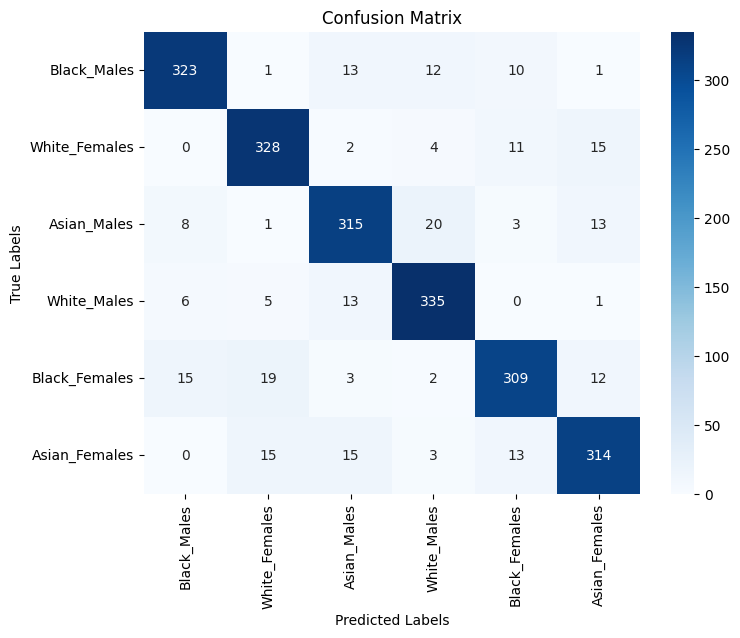

model_name,model_file_path,best_parameters,test_accuracy,test_f1,test_precision,test_recall,parameter_combinations
XGBClassifier,models/clf_demogpairs_xgb_vit-face-age_XGBClassifier.pkl,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'hist'}",0.8907407407407407,0.8906212951690908,0.8908537008452493,0.8907407407407408,54


In [6]:
evaluation_results, fold_results = u.evaluate_models(
    grid_models,
    X_train, y_train,
    X_test, y_test,
    model_prefix='models/clf_demogpairs_xgb_vit-face-age_',
    results_path='results/demogpairs_xgb_vit-face-age_'
)

sorted_results = pd.DataFrame(evaluation_results).sort_values(by='test_accuracy', ascending=False).to_dict('records')
u.html_br()
_dtable = u.display_table(sorted_results)

In [7]:
model, training_time = u.load_object('models/clf_demogpairs_xgb_vit-face-age_XGBClassifier.pkl')
u.h(5, 'Waktu Pelatihan (Jobs)')
u.seconds_to_time(round(training_time))

{'input_seconds': 51968.0,
 'days': 0,
 'hours': 14,
 'minutes': 26,
 'seconds': 8.0,
 'text': '0 hari 14 jam 26 menit 8.0 detik'}

In [8]:
u.h(5, 'Waktu Pelatihan')
times = [fr['Train Time Mean'] * 5 for fr in fold_results]
u.seconds_to_time(round(np.sum(times) + model.refit_time_))

{'input_seconds': 459576.0,
 'days': 5,
 'hours': 7,
 'minutes': 39,
 'seconds': 36.0,
 'text': '5 hari 7 jam 39 menit 36.0 detik'}

In [9]:
_dtable = u.display_table(fold_results, n_items=[4, 4], column_widths=['5%', '45%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%'])

No,Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Accuracy Mean,F1 Score Mean,Precision Mean,Recall Mean,Train Time Mean
1,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'hist'}",0.9051,0.9005,0.8976,0.8912,0.8964,0.8981,0.8981,0.8985,0.8981,239.1571
2,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 3, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'approx'}",0.9068,0.8999,0.8912,0.8964,0.8935,0.8976,0.8974,0.898,0.8976,3981.618
3,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.1, 'classifier__max_depth': 3, 'classifier__min_child_weight': 5, 'classifier__tree_method': 'approx'}",0.9022,0.8981,0.8918,0.8964,0.8964,0.897,0.8969,0.8973,0.897,2353.1763
4,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 3, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'hist'}",0.9051,0.8976,0.8883,0.8947,0.8958,0.8963,0.8962,0.8967,0.8963,237.6889
...,...,...,...,...,...,...,...,...,...,...,...
51,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'approx'}",0.8912,0.8814,0.8738,0.875,0.89,0.8823,0.882,0.8829,0.8823,2649.5728
52,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'hist'}",0.8924,0.8843,0.8773,0.8738,0.8837,0.8823,0.8819,0.8826,0.8823,365.9889
53,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'hist'}",0.8947,0.8767,0.8767,0.8762,0.8831,0.8815,0.8812,0.8819,0.8815,334.3973
54,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'approx'}",0.8883,0.8767,0.8704,0.8756,0.886,0.8794,0.8791,0.8799,0.8794,2678.01
